# Pricing Options: From Black–Scholes to Monte Carlo
## Step 3 — Geometric Brownian Motion

**Target audience:** second-year undergraduate students  
**Goal of this notebook:** understand the stochastic model used in Black–Scholes for the stock price, why it is called **geometric Brownian motion**, and why it leads to a **lognormal distribution** for the terminal price.

---

## Learning objectives

At the end of this notebook, the student should be able to:

- explain what Brownian motion represents in a financial model,
- interpret the stochastic differential equation
  $$dS_t = \mu S_t\,dt + \sigma S_t\,dW_t,$$
- understand the role of the parameters $\mu$ and $\sigma$,
- write the explicit solution of the Black–Scholes stock model,
- explain why the terminal price $S_T$ is lognormally distributed,
- distinguish between the distributions of **returns**, **log-returns**, and **prices**.


## 1. Why do we need a stock price model?

When we price an option, the payoff depends on the future stock price $S_T$.
So we need a mathematical model describing how the stock price evolves between today and maturity.

In the Black–Scholes framework, the stock price is modeled by a **continuous-time random process**.
The chosen process is called **geometric Brownian motion (GBM)**.

This model is simple enough to handle mathematically and rich enough to capture some basic features of stock prices:

- prices move randomly,
- prices remain positive,
- uncertainty accumulates over time.


## 2. Brownian motion: the source of randomness

The random ingredient in the Black–Scholes model is **Brownian motion**, denoted by $(W_t)_{t \ge 0}$.

Very informally, Brownian motion is a random path that:

- starts at 0,
- moves continuously,
- has independent increments,
- and whose increment over a small time interval of length $dt$ is roughly of size $\sqrt{dt}$.

In finance, Brownian motion is used to represent the unpredictable part of price movements.

You should think of $W_t$ as a cumulative random shock.


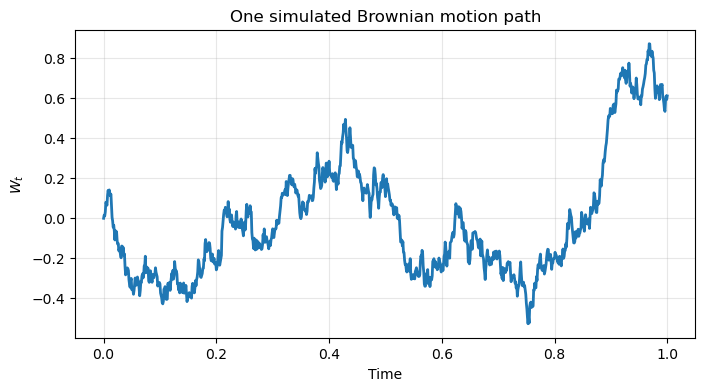

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

T = 1.0           # total time
n_steps = 1000    # number of time steps
dt = T / n_steps

time = np.linspace(0, T, n_steps + 1)

# Simulate one Brownian path
increments = np.sqrt(dt) * np.random.randn(n_steps)
W = np.concatenate([[0], np.cumsum(increments)])

plt.figure(figsize=(8, 4))
plt.plot(time, W, lw=2)
plt.title('One simulated Brownian motion path')
plt.xlabel('Time')
plt.ylabel('$W_t$')
plt.grid(True, alpha=0.3)
plt.show()


### Interpretation

This path is continuous but highly irregular.
It does not move smoothly like an ordinary deterministic curve.

That irregular behavior is exactly what makes Brownian motion useful for modeling uncertainty.


## 3. The Black–Scholes stock model

The Black–Scholes model assumes that the stock price $(S_t)$ satisfies the stochastic differential equation

$$
dS_t = \mu S_t\,dt + \sigma S_t\,dW_t.
$$

This equation has two parts:

### Drift term: $\mu S_t dt$

This is the **average trend** of the stock.
If there were no randomness, the stock would grow approximately at rate $\mu$.

### Diffusion term: $\sigma S_t dW_t$

This is the **random part**.
The parameter $\sigma > 0$ is called the **volatility**.
It controls the strength of random fluctuations.

So the model says:

> the stock price evolves with a systematic trend and a random shock.


## 4. Why is it called *geometric* Brownian motion?

It is called **Brownian motion** because the randomness comes from $W_t$.
It is called **geometric** because the randomness acts **multiplicatively** on the stock price.

Notice that both the drift and diffusion terms are proportional to $S_t$.
This means:

- when the stock price is large, its fluctuations tend to be large in absolute value,
- when the stock price is small, its fluctuations tend to be small in absolute value.

This is more realistic than adding the same absolute noise regardless of the price level.


## 5. Discrete-time intuition

To understand the equation better, we can rewrite it informally over a small time interval $\Delta t$ as

$$
\Delta S \approx \mu S\,\Delta t + \sigma S\,\Delta W.
$$

Since a Brownian increment satisfies roughly

$$
\Delta W \approx \sqrt{\Delta t}\, Z,
$$

where $Z \sim \mathcal{N}(0,1)$, we get

$$
\Delta S \approx \mu S\,\Delta t + \sigma S\sqrt{\Delta t}\, Z.
$$

This tells us two important things:

- the average change over a small interval is proportional to $\Delta t$,
- the random fluctuation is proportional to $\sqrt{\Delta t}$.

This scaling is a key feature of diffusion models.


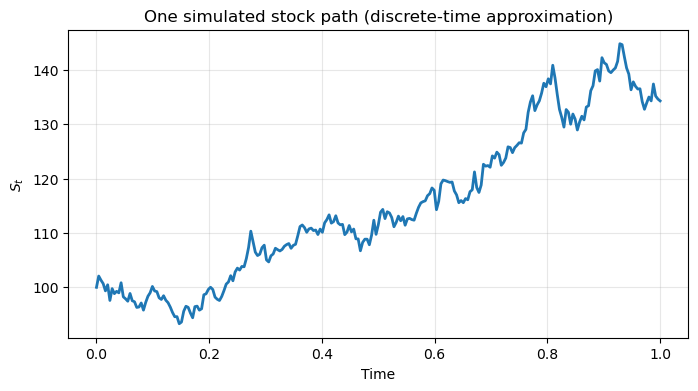

In [2]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(1)

# Parameters
S0 = 100
mu = 0.08
sigma = 0.2
T = 1.0
n_steps = 252

dt = T / n_steps
time = np.linspace(0, T, n_steps + 1)

# Euler-type simulation of GBM
Z = np.random.randn(n_steps)
S = np.zeros(n_steps + 1)
S[0] = S0
for i in range(n_steps):
    S[i+1] = S[i] + mu * S[i] * dt + sigma * S[i] * np.sqrt(dt) * Z[i]

plt.figure(figsize=(8, 4))
plt.plot(time, S, lw=2)
plt.title('One simulated stock path (discrete-time approximation)')
plt.xlabel('Time')
plt.ylabel('$S_t$')
plt.grid(True, alpha=0.3)
plt.show()


### Interpretation

The path is random, but it remains centered around an upward trend because $\mu > 0$.
If we increased $\sigma$, the path would become much more irregular.


## 6. Explicit solution of the GBM model

A remarkable property of geometric Brownian motion is that the stochastic differential equation has a closed-form solution:

$$
S_t = S_0 \exp\left(\left(\mu - \frac{1}{2}\sigma^2\right)t + \sigma W_t\right).
$$

This formula is extremely important.
It shows that the stock price is obtained by exponentiating a Gaussian random variable.

This immediately explains why the stock price is always positive:

$$
S_t > 0 \quad \text{for all } t.
$$

This is one of the main reasons why GBM is attractive as a price model.


## 7. Why does the term $-\frac{1}{2}\sigma^2$ appear?

Students often wonder why the solution contains

$$
\mu - \frac{1}{2}\sigma^2
$$

instead of just $\mu$.

The reason comes from **Itô calculus**.
When applying Itô's formula to $\log S_t$, an extra correction term appears.

The result is:

$$
\log S_t = \log S_0 + \left(\mu - \frac{1}{2}\sigma^2\right)t + \sigma W_t.
$$

At this stage, the most important message is not the technical derivation, but the consequence:

> **the logarithm of the price is Gaussian.**


## 8. Distribution of the terminal price

Since $W_T \sim \mathcal{N}(0,T)$, we obtain

$$
\log S_T \sim \mathcal{N}\left(\log S_0 + \left(\mu - \frac{1}{2}\sigma^2\right)T,\; \sigma^2 T\right).
$$

Therefore:

- **log-price** is normal,
- **price** is lognormal.

This is a central result of the Black–Scholes model.


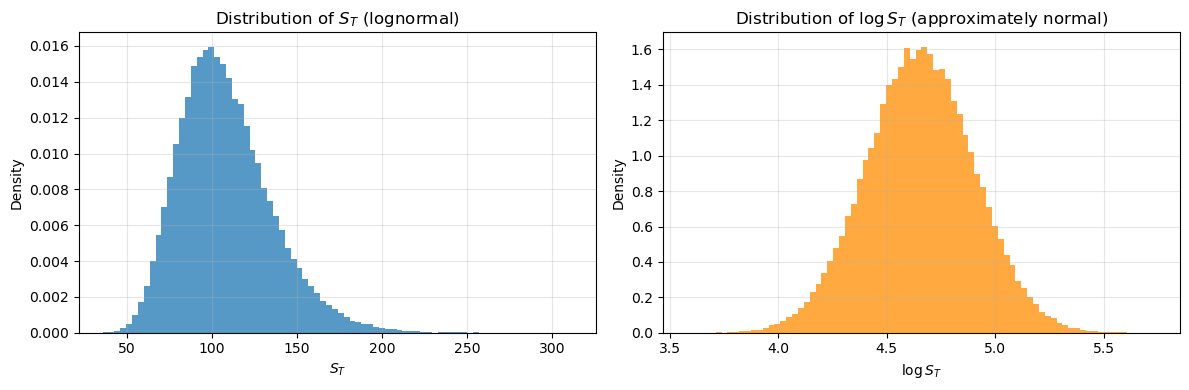

In [3]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(7)

S0 = 100
mu = 0.08
sigma = 0.25
T = 1.0
n = 100000

Z = np.random.randn(n)
ST = S0 * np.exp((mu - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z)
log_ST = np.log(ST)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(ST, bins=80, density=True, alpha=0.75)
axes[0].set_title('Distribution of $S_T$ (lognormal)')
axes[0].set_xlabel('$S_T$')
axes[0].set_ylabel('Density')
axes[0].grid(True, alpha=0.3)

axes[1].hist(log_ST, bins=80, density=True, alpha=0.75, color='darkorange')
axes[1].set_title('Distribution of $\log S_T$ (approximately normal)')
axes[1].set_xlabel('$\log S_T$')
axes[1].set_ylabel('Density')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### Interpretation

- The histogram of $S_T$ is **right-skewed**.
  This is the typical shape of a lognormal distribution.

- The histogram of $\log S_T$ is much more **symmetric** and bell-shaped.
  This is the typical shape of a normal distribution.

So the Black–Scholes model does **not** assume that prices are normally distributed.
It assumes that **log-prices** are normally distributed.


## 9. Returns vs. log-returns

It is very important not to confuse the different quantities.

### Simple return over $[0,T]$

The simple return is

$$
\frac{S_T - S_0}{S_0}.
$$

### Log-return over $[0,T]$

The log-return is

$$
\log\left(\frac{S_T}{S_0}\right).
$$

Under the GBM model, the **log-return** is Gaussian:

$$
\log\left(\frac{S_T}{S_0}\right) \sim \mathcal{N}\left(\left(\mu - \frac{1}{2}\sigma^2\right)T,\; \sigma^2 T\right).
$$

This is one of the main theoretical motivations of the model.


## 10. Role of the parameters

The parameters of the model each have a clear interpretation.

### The initial price $S_0$
This is the known stock price today.

### The drift $\mu$
This controls the average growth rate of the stock under the real-world model.

### The volatility $\sigma$
This measures the intensity of random fluctuations.
A larger $\sigma$ means a more uncertain asset.

### The time horizon $T$
The longer the horizon, the more uncertainty accumulates.


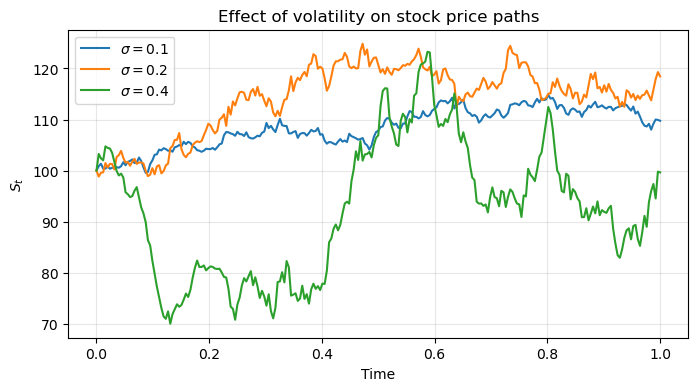

In [4]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(10)

S0 = 100
mu = 0.05
T = 1.0
n_steps = 252
dt = T / n_steps
time = np.linspace(0, T, n_steps + 1)

sigmas = [0.1, 0.2, 0.4]
colors = ['tab:blue', 'tab:orange', 'tab:green']

plt.figure(figsize=(8, 4))
for sigma, color in zip(sigmas, colors):
    Z = np.random.randn(n_steps)
    W = np.concatenate([[0], np.cumsum(np.sqrt(dt) * Z)])
    S = S0 * np.exp((mu - 0.5 * sigma**2) * time + sigma * W)
    plt.plot(time, S, label=f'$\\sigma={sigma}$', color=color)

plt.title('Effect of volatility on stock price paths')
plt.xlabel('Time')
plt.ylabel('$S_t$')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


### Interpretation

As volatility increases, the trajectories become more dispersed and more irregular.
This is why volatility is one of the most important parameters in option pricing.


## 11. Expected value and variance under GBM

For geometric Brownian motion, one can show that

$$
\mathbb{E}[S_T] = S_0 e^{\mu T}.
$$

This means that the expected stock price grows exponentially with rate $\mu$.

The variance also increases with time and volatility, reflecting growing uncertainty.

For option pricing, however, the key quantity will not be the real-world drift $\mu$, but the **risk-neutral drift**, which will later become the risk-free rate $r$.


## 12. Why GBM is useful for option pricing

Geometric Brownian motion is useful because it gives us:

- a positive stock price,
- a tractable mathematical model,
- an explicit formula for $S_T$,
- and a known probability distribution for the terminal price.

This makes it possible to derive the Black–Scholes formula and also to simulate stock prices numerically.


## 13. Limitations of geometric Brownian motion

Even though GBM is elegant and useful, it is not perfect.
Real stock prices may exhibit:

- jumps,
- changing volatility,
- heavy tails,
- volatility clustering.

So GBM should be understood as a **benchmark model**, not a perfect description of the real market.


## 14. Summary

### Main ideas to remember

- In the Black–Scholes model, the stock price follows
  $$dS_t = \mu S_t\,dt + \sigma S_t\,dW_t.$$
- Brownian motion provides the random shocks.
- The stock price follows a **geometric Brownian motion**.
- The explicit solution is
  $$S_t = S_0 \exp\left(\left(\mu - \frac{1}{2}\sigma^2\right)t + \sigma W_t\right).$$
- Therefore, $\log S_T$ is normal and $S_T$ is lognormal.
- Volatility controls the strength of randomness.
- GBM is a useful benchmark, even though it is not fully realistic.


## 15. Exercises for the student

1. In the equation
   $$dS_t = \mu S_t dt + \sigma S_t dW_t,$$
   what is the role of $\mu$?
2. What is the role of $\sigma$?
3. Why does GBM guarantee that prices remain positive?
4. Is $S_T$ normally distributed or lognormally distributed?
5. Is the log-return normally distributed under GBM?
6. Why is volatility so important in option pricing?


## 16. What comes next?

Now that we understand the stock dynamics, the next natural step is:

### **Notebook 4 — The Black–Scholes formula**

In the next notebook, we can explain:

- the idea of dynamic hedging,
- the Black–Scholes partial differential equation,
- the closed-form formula for European call and put options,
- the interpretation of each parameter in the formula.
